正在构建高维 GUE 随机矩阵...
正在对角化提取实数特征值...
正在绘制真理的形状...


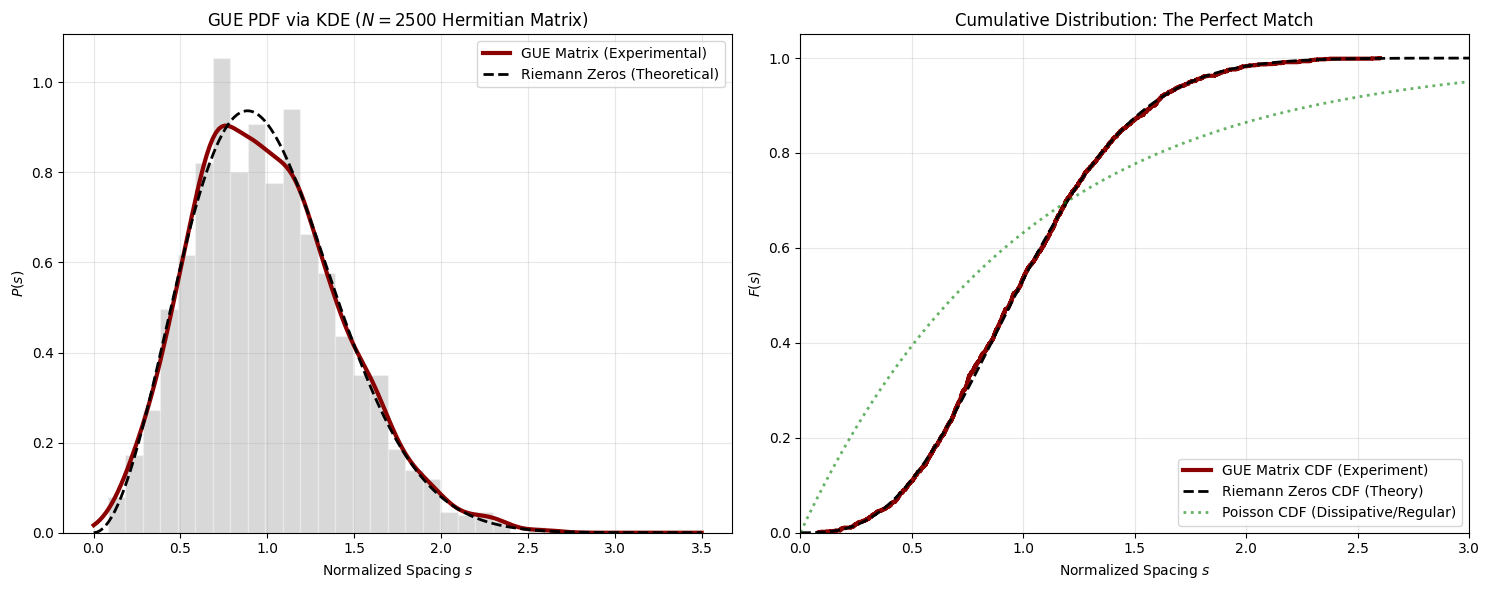

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.special import erf

# ==========================================
# 1. 构造“上帝的骰子”：随机埃尔米特矩阵 (GUE)
# ==========================================
print("正在构建高维 GUE 随机矩阵...")
N = 2500  # 矩阵维度 (相当于量子系统的能级数)

# 步骤 A: 生成一个纯随机的复数矩阵 (毫无结构的白噪声)
A = np.random.randn(N, N) + 1j * np.random.randn(N, N)

# 步骤 B: 强行赋予它“物理意义” (能量守恒/时间反演对称破缺)
# 构造埃尔米特矩阵 H = (A + A的共轭转置) / 2
H = (A + A.conj().T) / 2.0 

# ==========================================
# 2. 提取特征谱与“体区展开” (Bulk Unfolding)
# ==========================================
print("正在对角化提取实数特征值...")
# 埃尔米特矩阵的特征值必定是实数 (代表物理上可观测的能量或零点)
eigvals = np.linalg.eigvalsh(H)

# 【核心教学点】：Wigner 半圆律
# GUE 矩阵的特征值密度在整体上呈半圆形。两端的特征值太稀疏，不具有普适性。
# 所以我们像切西瓜一样，只取中间最核心、最密集的 60% (称为 Bulk 体区)。
keep_ratio = 0.6
start_idx = int(N * (1 - keep_ratio) / 2)
end_idx = int(N * (1 + keep_ratio) / 2)
bulk_eigvals = eigvals[start_idx:end_idx]

# 计算间距并均值归一化 (熟悉的配方)
spacings = np.diff(bulk_eigvals)
s = spacings / np.mean(spacings)

# ==========================================
# 3. 定义理论函数
# ==========================================
def gue_pdf(x):
    # Wigner Surmise for GUE: 强烈的能级排斥 (~s^2)
    return (32 / (np.pi**2)) * (x**2) * np.exp(-(4 / np.pi) * (x**2))

def gue_cdf(x):
    return erf(2 * x / np.sqrt(np.pi)) - (4 * x / np.pi) * np.exp(-4 * x**2 / np.pi)

def poisson_cdf(x):
    return 1 - np.exp(-x)

# ==========================================
# 4. 绘图：见证完美重合的“奇迹时刻”
# ==========================================
print("正在绘制真理的形状...")
plt.figure(figsize=(15, 6))
x_plot = np.linspace(0.001, 3.5, 200)

# --- 左图：KDE vs GUE PDF ---
plt.subplot(1, 2, 1)
# 画个浅色的直方图做底色
plt.hist(s, bins='fd', density=True, alpha=0.3, color='gray', edgecolor='white')

# 核心 KDE 曲线
kde = gaussian_kde(s)
plt.plot(x_plot, kde(x_plot), color='darkred', lw=3, label='GUE Matrix (Experimental)')
plt.plot(x_plot, gue_pdf(x_plot), 'k--', lw=2, label='Riemann Zeros (Theoretical)')

plt.title(rf"GUE PDF via KDE ($N={N}$ Hermitian Matrix)")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$P(s)$")
plt.legend()
plt.grid(alpha=0.3)

# --- 右图：CDF 终极对决 ---
plt.subplot(1, 2, 2)
s_sorted = np.sort(s)
y_ecdf = np.arange(1, len(s_sorted) + 1) / len(s_sorted)

# 画出我们手动捏的矩阵的经验 CDF
plt.step(s_sorted, y_ecdf, where='post', color='darkred', lw=3, label='GUE Matrix CDF (Experiment)')
# 黎曼零点理论 CDF
plt.plot(x_plot, gue_cdf(x_plot), 'k--', lw=2, label='Riemann Zeros CDF (Theory)')
# 被抛弃的泊松 CDF
plt.plot(x_plot, poisson_cdf(x_plot), 'g:', lw=2, alpha=0.6, label='Poisson CDF (Dissipative/Regular)')

plt.title(r"Cumulative Distribution: The Perfect Match")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$F(s)$")
plt.xlim(0, 3)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()